In [1]:
import matplotlib.pyplot as plt
import numpy as np

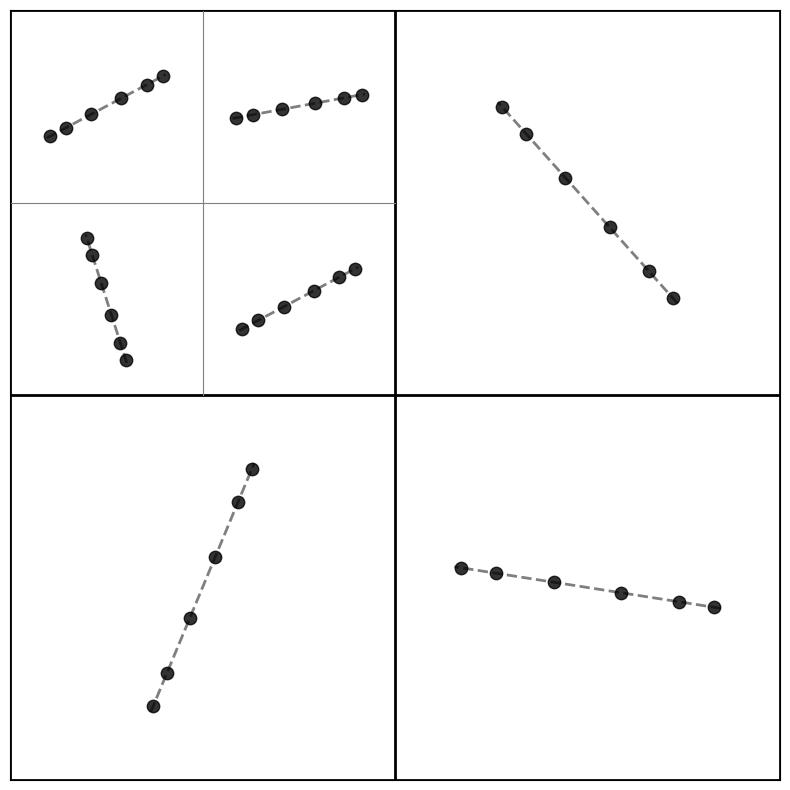

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ========== CONFIGURATION ==========
world_size = 4.0
n_major = 2
major_size = world_size / n_major   # = 2.0

# Choose which major cell to refine (col, row) from bottom-left (0,0)
# For top-left cell: col=0 (left), row=1 (top)
refine_col, refine_row = 0, 1

refinement = 2                     # split into 2x2 smaller cells
minor_size = major_size / refinement   # = 1.0

particles_per_cell = 6
line_length_factor = 0.7
np.random.seed(42)

# ========== BUILD LEAF CELLS ==========
leaf_cells = []   # each: (x0, y0, x1, y1)

# Add unrefined major cells (skip the refined one)
for col in range(n_major):          # x-direction
    for row in range(n_major):      # y-direction
        if (col, row) == (refine_col, refine_row):
            continue
        x0 = col * major_size
        y0 = row * major_size
        x1 = x0 + major_size
        y1 = y0 + major_size
        leaf_cells.append((x0, y0, x1, y1))

# Add subcells of the refined cell
ref_x0 = refine_col * major_size
ref_y0 = refine_row * major_size
for mi in range(refinement):
    for mj in range(refinement):
        x0 = ref_x0 + mi * minor_size
        y0 = ref_y0 + mj * minor_size
        x1 = x0 + minor_size
        y1 = y0 + minor_size
        leaf_cells.append((x0, y0, x1, y1))

# ========== SPACING FUNCTIONS ==========
def cubic_ends_sparse(t):
    """
    Maps t ∈ [0,1] to position in [-1, 1] with derivative small in the middle
    and large at ends -> particles cluster at the center.
    """
    return 2.0 * (t - 0.5)**3

def cosine_ends_dense(t):
    """
    Maps t ∈ [0,1] to position in [-1, 1] with derivative large in the middle
    and small at ends -> particles cluster at ends (dense at boundaries).
    """
    return np.sin(np.pi * (t - 0.5))

# Choose one spacing function (or write your own)
spacing_func = cubic_ends_sparse   # <-- change this to test other functions

def particles_in_cell(x0, y0, x1, y1, n_particles, angle_rad, func=cosine_ends_dense):
    """
    Generate points on a line through the cell center.
    Positions are given by func(t) * half_len, where t is equally spaced in [0,1].
    """
    cx = (x0 + x1) / 2.0
    cy = (y0 + y1) / 2.0
    cell_width = x1 - x0
    line_length = line_length_factor * cell_width
    half_len = line_length /2 
    dx = np.cos(angle_rad)
    dy = np.sin(angle_rad)

    if n_particles == 1:
        offsets = [0.0]
    else:
        t = np.linspace(0.1, 0.9, n_particles)          # equally spaced parameter
        # Normalized positions in [-1, 1] after applying func
        norm_pos = func(t)
        # Scale to [-half_len, half_len]
        offsets = norm_pos * half_len

    points = []
    margin = 0.1 * cell_width
    for t_val in offsets:
        x = cx + t_val * dx
        y = cy + t_val * dy
        # Clip to keep strictly inside cell
        x = np.clip(x, x0 + margin, x1 - margin)
        y = np.clip(y, y0 + margin, y1 - margin)
        points.append((x, y))
    return points


# ========== PLOTTING ==========
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')

# 1. Major grid lines (thick black)
for i in range(n_major + 1):
    x = i * major_size
    ax.axvline(x, color='black', linewidth=2)
    ax.axhline(x, color='black', linewidth=2)

# 2. Internal grid lines ONLY inside the refined cell (thin gray)
#    Draw line segments instead of full axes lines
for mi in range(1, refinement):
    x = ref_x0 + mi * minor_size
    # vertical line from bottom to top of the refined cell
    ax.plot([x, x], [ref_y0, ref_y0 + major_size], color='gray', linewidth=0.8)
for mj in range(1, refinement):
    y = ref_y0 + mj * minor_size
    # horizontal line from left to right of the refined cell
    ax.plot([ref_x0, ref_x0 + major_size], [y, y], color='gray', linewidth=0.8)
    
    
# 3. Draw particles in every leaf cell
for (x0, y0, x1, y1) in leaf_cells:
    angle = np.random.uniform(0, np.pi)      # arbitrary rotation per cell
    positions = particles_in_cell(x0, y0, x1, y1, particles_per_cell, angle)
    xs, ys = zip(*positions)
    ax.scatter(xs, ys, s=80, c='black', edgecolors='black', zorder=5, alpha=0.8)
    
    # (Optional) draw the underlying line – uncomment to see
    cx, cy = (x0+x1)/2, (y0+y1)/2
    l_len = line_length_factor * (x1-x0)
    dx, dy = np.cos(angle), np.sin(angle)
    ax.plot([cx - l_len/2*dx, cx + l_len/2*dx],
             [cy - l_len/2*dy, cy + l_len/2*dy], color = 'black', linestyle = "--", linewidth=2, alpha=0.5)

# 4. Formatting
ax.set_xlim(0, world_size)
ax.set_ylim(0, world_size)
ax.set_xticks([])
ax.set_yticks([])
#ax.set_title("2x2 grid with refinement only in top‑left cell\nEach cell has a rotated line of particles", fontsize=10)
plt.tight_layout()
plt.savefig("refined_grid_particles.png", dpi=500)
plt.show()